# Nama: PANDU HARIANDIKA PRATAMA
# NIM: 4222301076
# Kelas: 6 C

In [27]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

## Load Our Dataset

In [28]:
df = pd.read_csv('WineQT.csv')
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


## EDA

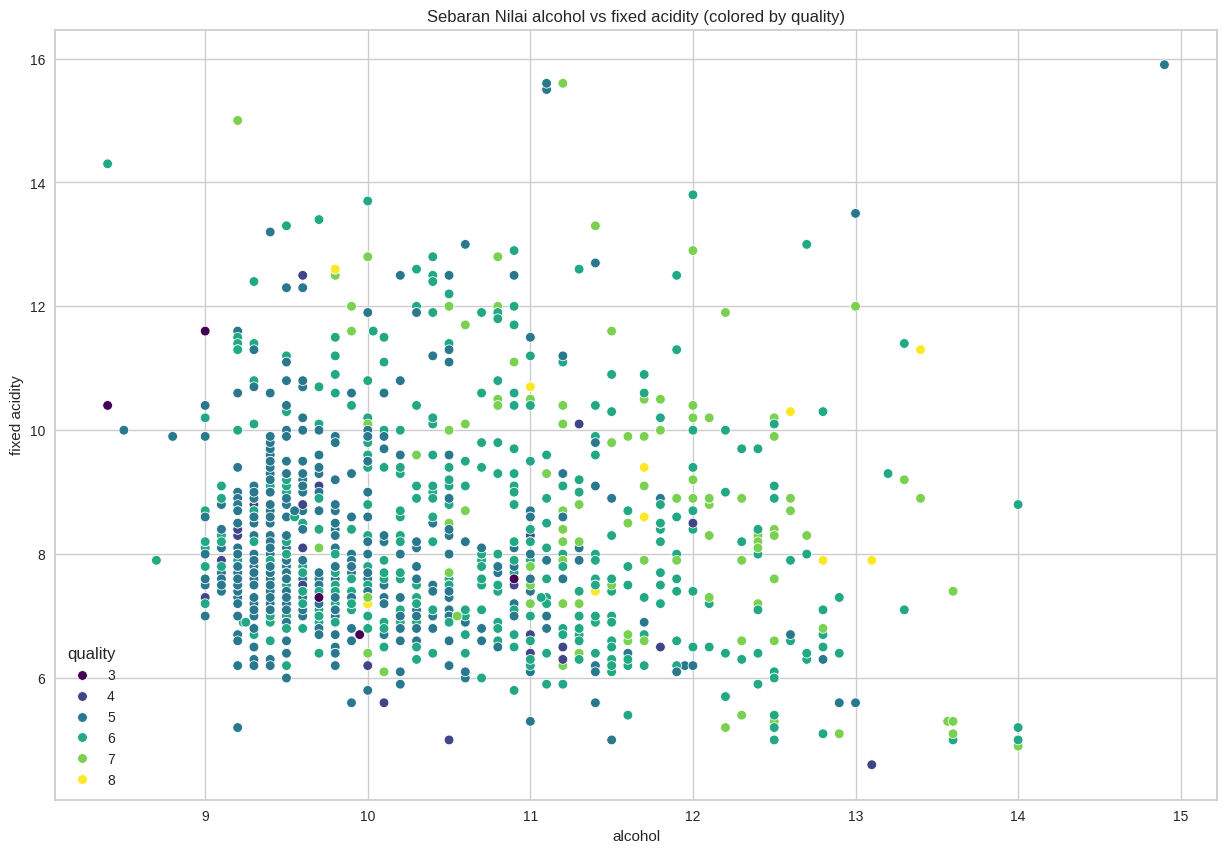

In [29]:
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='alcohol', y='fixed acidity', hue='quality', palette='viridis')
plt.title('Sebaran Nilai alcohol vs fixed acidity (colored by quality)')
plt.show()

In [30]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


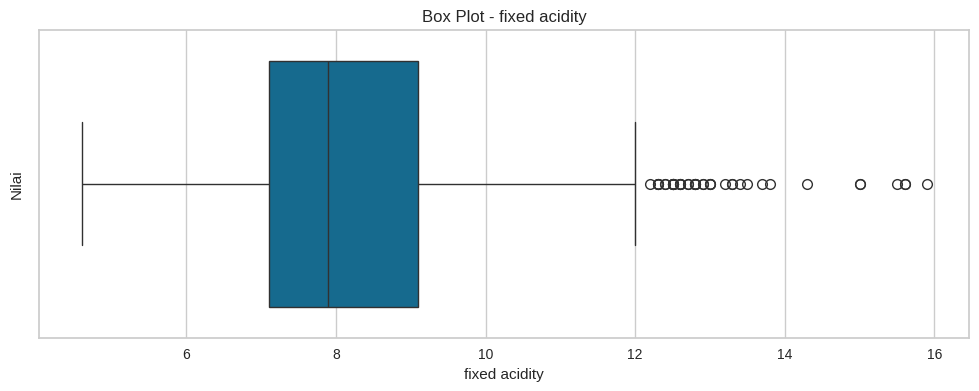

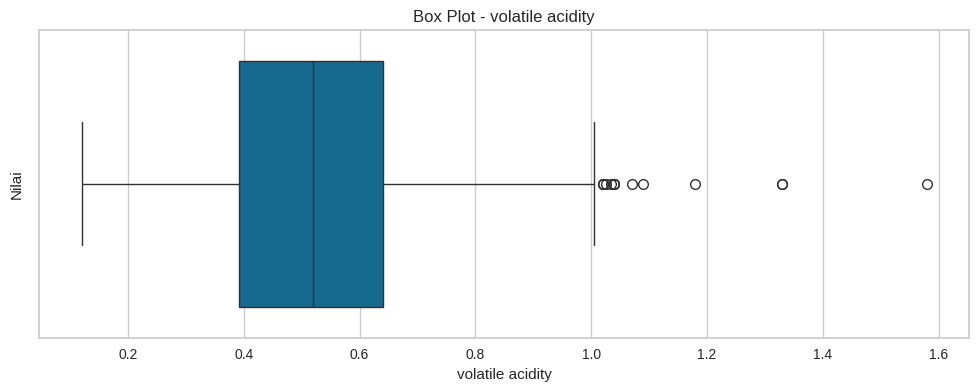

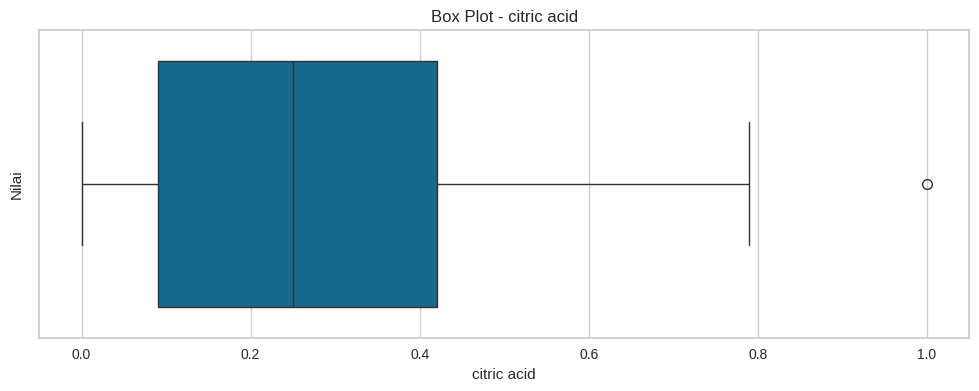

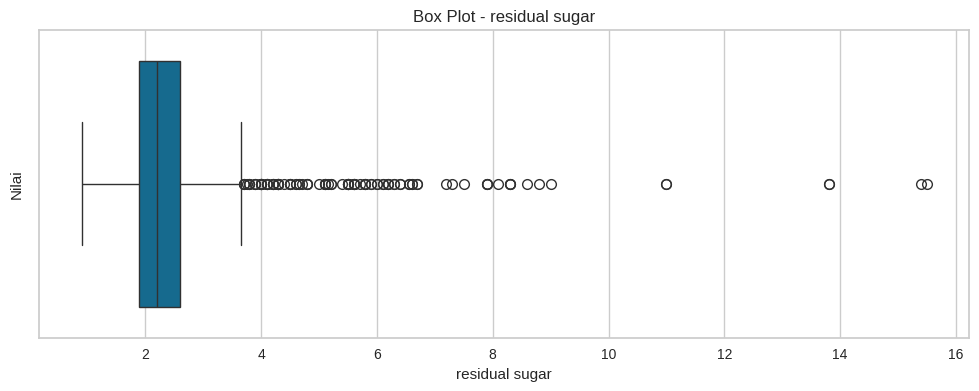

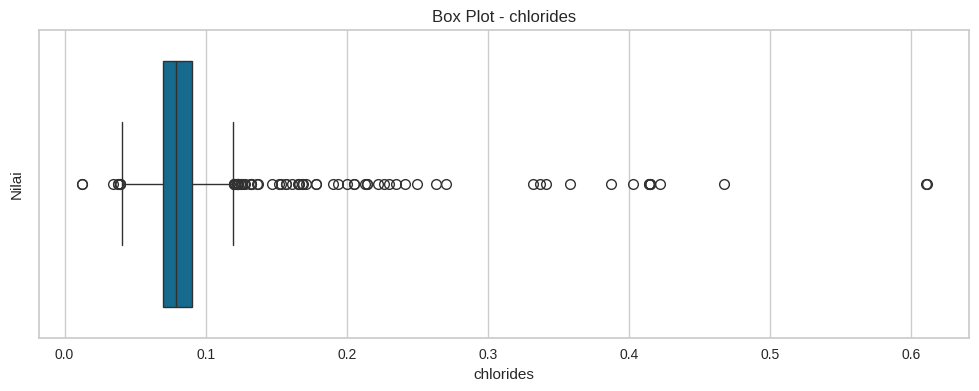

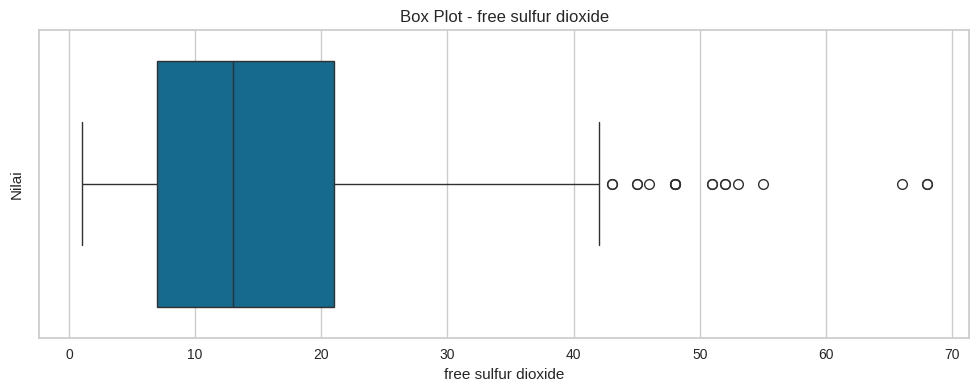

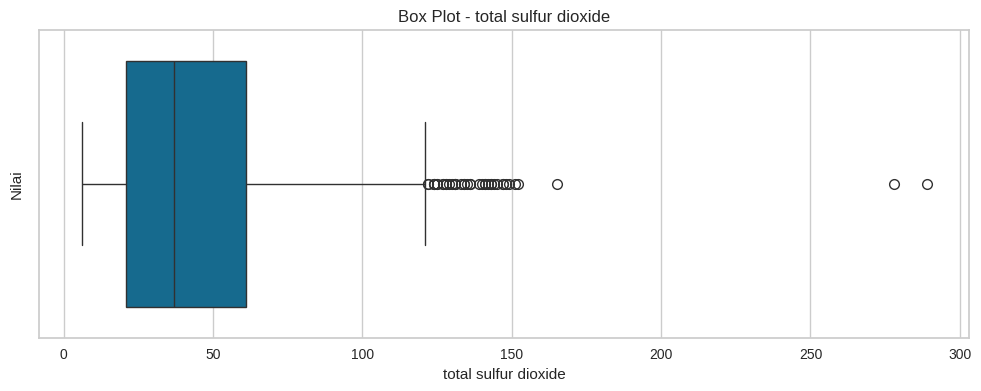

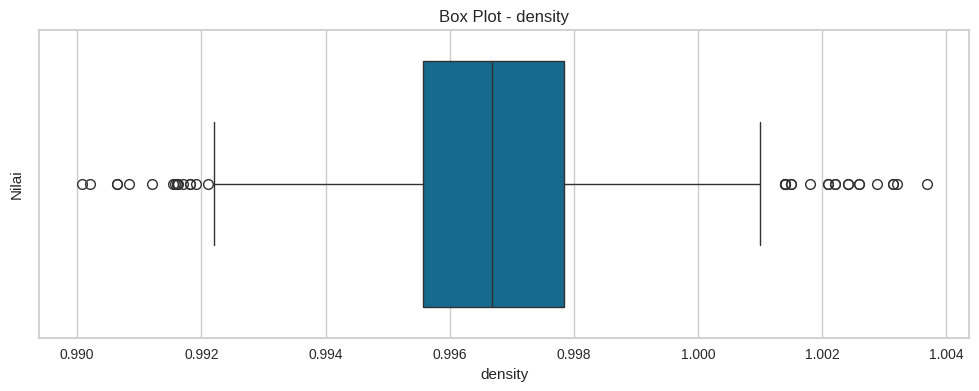

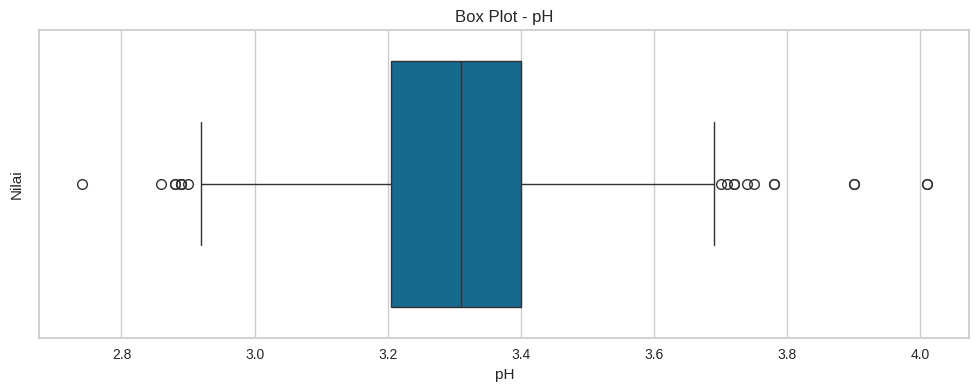

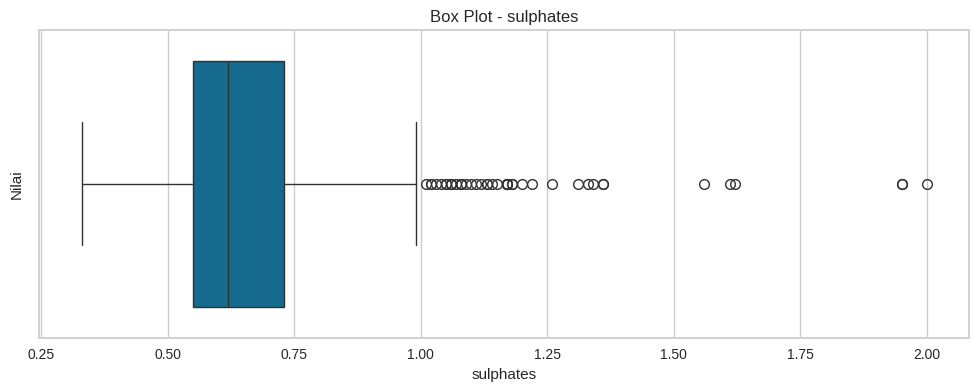

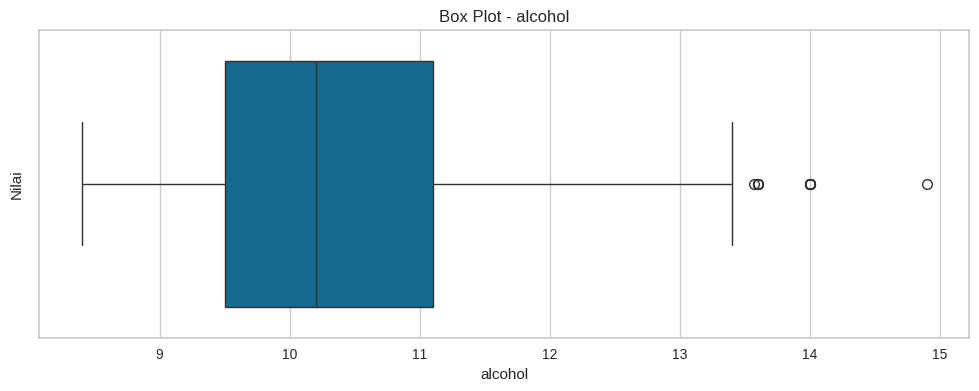

In [31]:
fitur_columns = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
                 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide',
                 'density', 'pH', 'sulphates', 'alcohol']

for col in fitur_columns:
    plt.figure(figsize=(12, 4))
    sns.boxplot(x=col, data=df)
    plt.title(f'Box Plot - {col}')
    plt.xlabel(col)
    plt.ylabel('Nilai')
    plt.show()

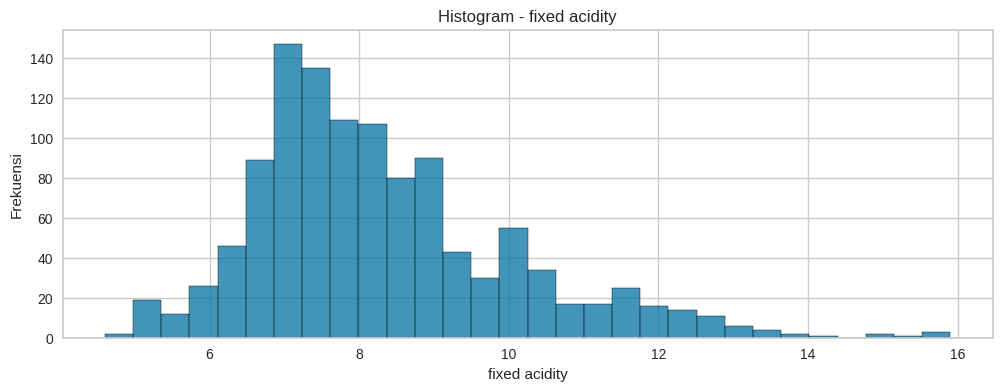

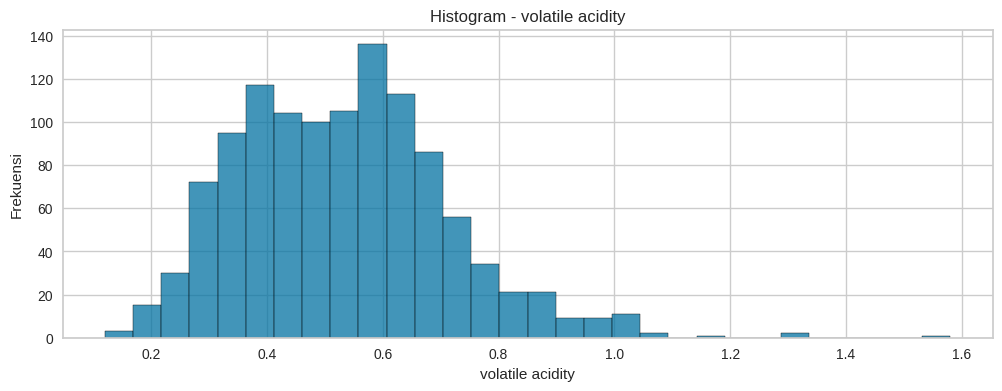

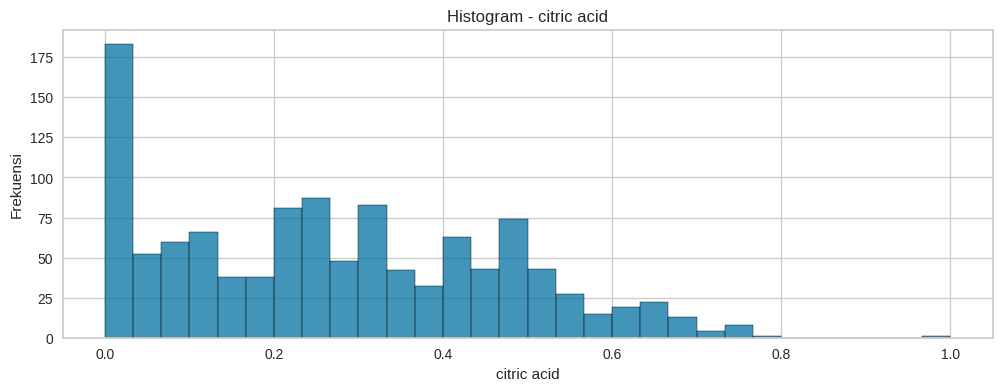

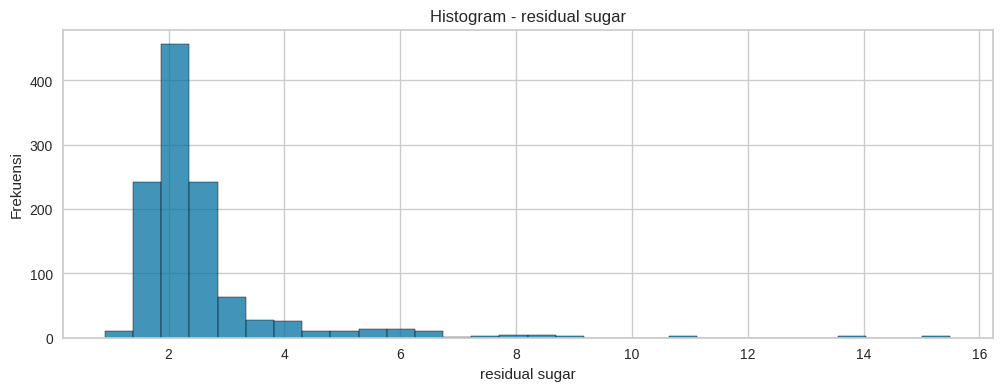

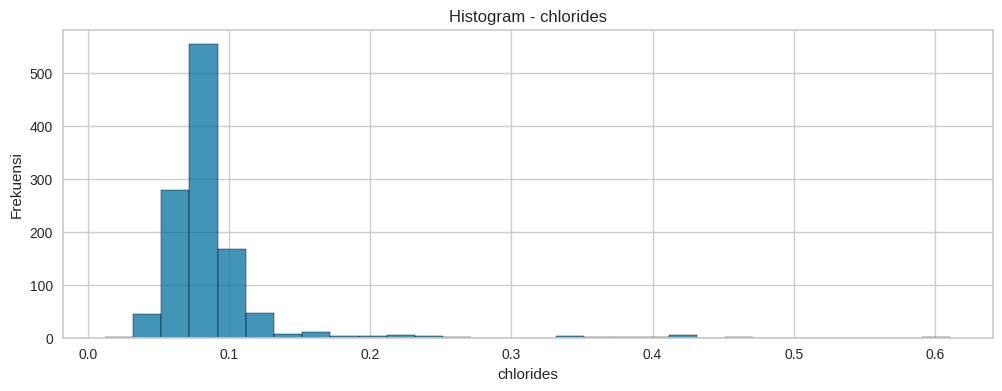

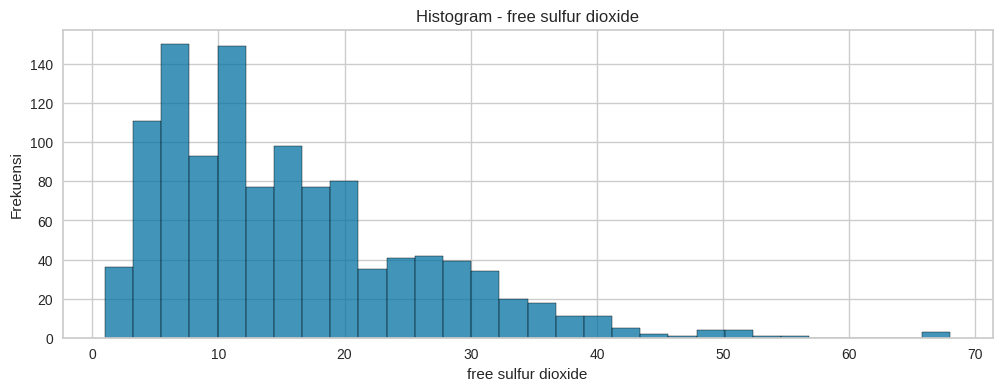

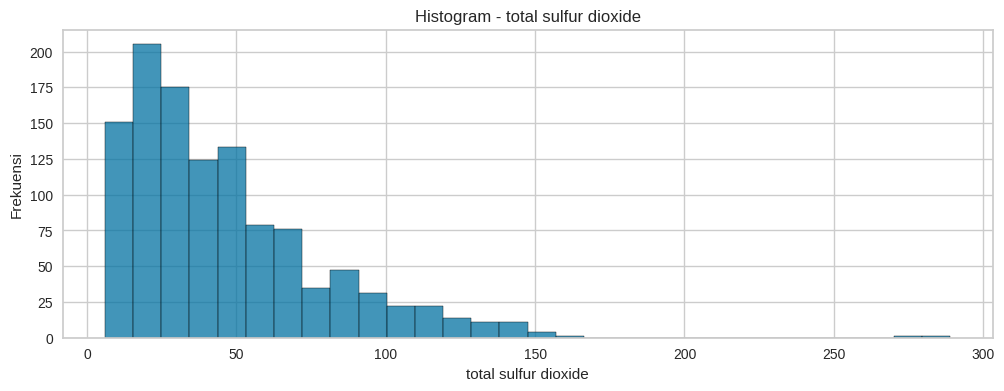

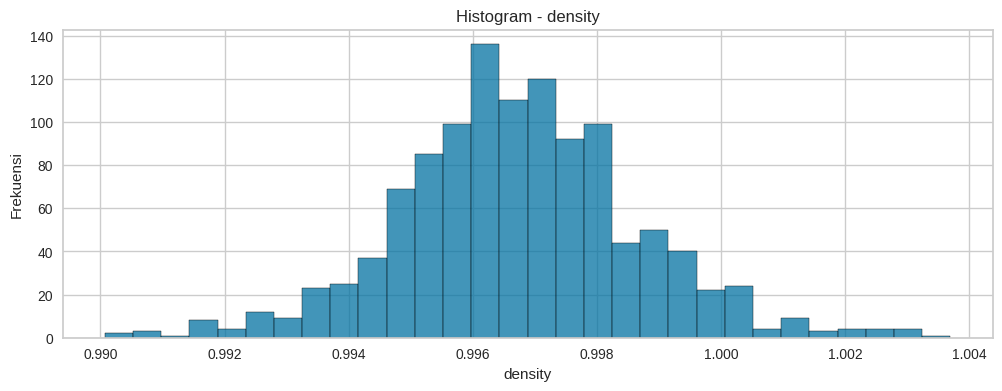

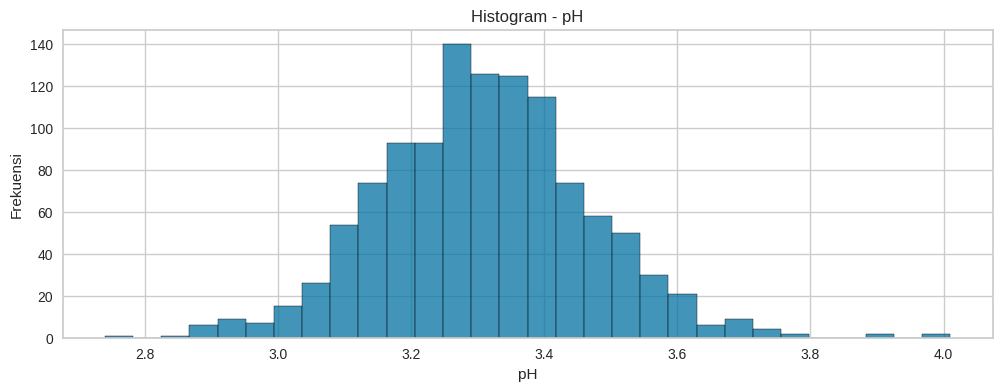

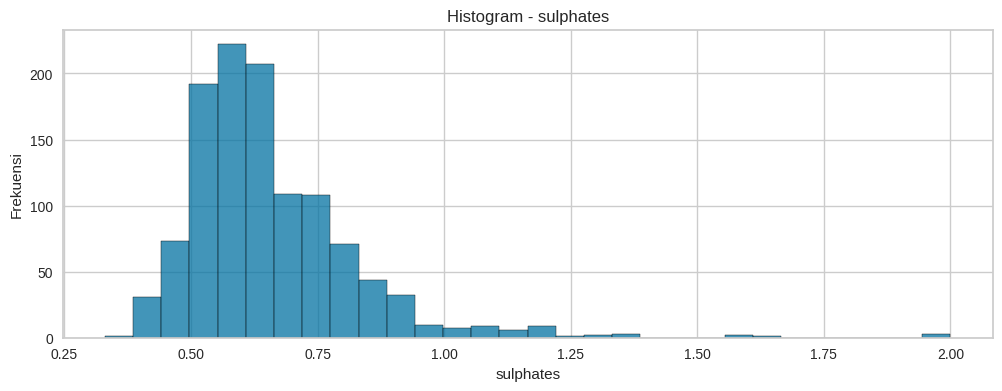

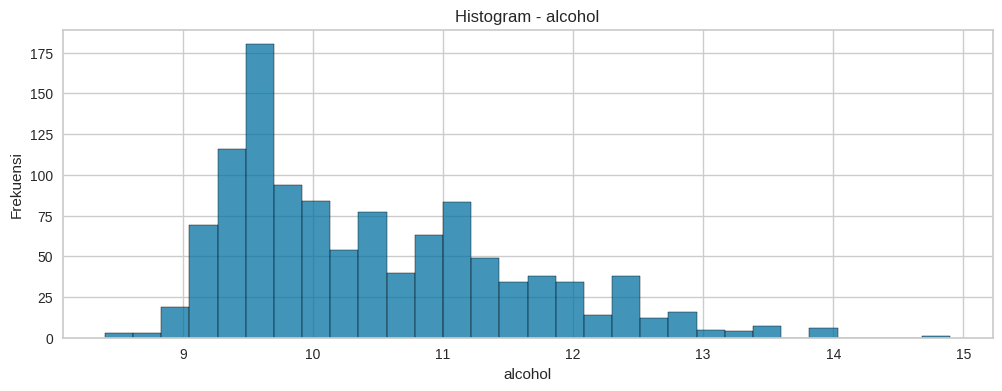

In [32]:
for col in fitur_columns:
    plt.figure(figsize=(12, 4))
    sns.histplot(df[col], bins=30, kde=False)
    plt.title(f'Histogram - {col}')
    plt.xlabel(col)
    plt.ylabel('Frekuensi')
    plt.show()

## Feature Engineering
* Unsupervised tidak perlu dilakukan splitting
1. Drop Duplikat
2. Outlier Handling (opsional)
3. Feature Scaling

In [33]:
print(f"Dataframe dimension before duplication drop {df.shape[0]}")

df = df.drop_duplicates().reset_index(drop=True)

print(f"Dataframe dimension after duplication drop {df.shape[0]}")

Dataframe dimension before duplication drop 1143
Dataframe dimension after duplication drop 1143


dari hasil running program diatas, kita dapat mengetahui apakah terdapat data yang duplikat atau tidak

In [34]:
fitur_columns = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
                 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide',
                 'density', 'pH', 'sulphates', 'alcohol']

X = df[fitur_columns].values
y = df['quality'].values  # label kualitas wine (sebagai anotator label)

In [35]:
from sklearn.preprocessing import StandardScaler
X_std = StandardScaler().fit_transform(X)
df_scalling = pd.DataFrame(data=X_std, columns=fitur_columns)
df_scalling.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
count,1.143000e+03,1.143000e+03,1.143000e+03,1.143000e+03,1.143000e+03,1.143000e+03,1.143000e+03,1.143000e+03,1.143000e+03,1.143000e+03,1.143000e+03
mean,-3.729883e-16,4.475860e-16,2.486589e-17,1.554118e-16,8.081413e-17,-5.594825e-17,9.946355e-17,5.783805e-14,-8.454402e-16,4.973178e-17,-1.193563e-15
std,1.000438e+00,1.000438e+00,1.000438e+00,1.000438e+00,1.000438e+00,1.000438e+00,1.000438e+00,1.000438e+00,1.000438e+00,1.000438e+00,1.000438e+00
min,-2.124483e+00,-2.290883e+00,-1.365027e+00,-1.204252e+00,-1.585988e+00,-1.426458e+00,-1.218108e+00,-3.461348e+00,-3.646432e+00,-1.924024e+00,-1.887834e+00
25%,-6.933192e-01,-7.732388e-01,-9.072439e-01,-4.664214e-01,-3.583880e-01,-8.408632e-01,-7.603412e-01,-6.030539e-01,-6.769982e-01,-6.323694e-01,-8.709366e-01
50%,-2.353469e-01,-6.314838e-02,-9.340780e-02,-2.450722e-01,-1.678983e-01,-2.552689e-01,-2.720568e-01,-2.619819e-02,-6.480857e-03,-2.213884e-01,-2.238203e-01
75%,4.516116e-01,6.051720e-01,7.712930e-01,5.006018e-02,6.492241e-02,5.255235e-01,4.603699e-01,5.792404e-01,5.682483e-01,4.244390e-01,6.081863e-01
max,4.344377e+00,5.840349e+00,3.721449e+00,9.568078e+00,1.109216e+01,5.112679e+00,7.418423e+00,3.616827e+00,4.463634e+00,7.880809e+00,4.121103e+00


In [36]:
X_std

array([[-0.52157961,  0.93933222, -1.36502663, ...,  1.27069495,
        -0.57365783, -0.96338181],
       [-0.29259344,  1.94181282, -1.36502663, ..., -0.70892755,
         0.1308811 , -0.59360107],
       [-0.29259344,  1.27349242, -1.16156762, ..., -0.32577481,
        -0.04525363, -0.59360107],
       ...,
       [-1.20853813,  0.38239855, -0.9581086 , ...,  0.88754221,
        -0.45623467,  0.05351522],
       [-1.38027776,  0.10393172, -0.8563791 , ...,  1.33455374,
         0.60057372,  0.70063152],
       [-1.38027776,  0.6330187 , -0.75464959, ...,  1.65384769,
         0.30701583, -0.22382033]])

In [37]:
df_scalling

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,-0.521580,0.939332,-1.365027,-0.466421,-0.231395,-0.450467,-0.363610,0.555854,1.270695,-0.573658,-0.963382
1,-0.292593,1.941813,-1.365027,0.050060,0.234247,0.915920,0.643477,0.036165,-0.708928,0.130881,-0.593601
2,-0.292593,1.273492,-1.161568,-0.171289,0.107253,-0.060071,0.246745,0.140103,-0.325775,-0.045254,-0.593601
3,1.653789,-1.399789,1.483400,-0.466421,-0.252560,0.135127,0.429852,0.659792,-0.964363,-0.456235,-0.593601
4,-0.521580,0.939332,-1.365027,-0.466421,-0.231395,-0.450467,-0.363610,0.555854,1.270695,-0.573658,-0.963382
...,...,...,...,...,...,...,...,...,...,...,...
1138,-1.151292,-0.118842,-0.703785,-0.171289,-0.231395,1.306316,-0.180503,-0.514707,0.695966,0.541862,0.515741
1139,-0.865059,0.493785,-0.958109,-0.466421,-0.400719,1.208717,-0.241539,-0.114545,0.695966,0.952843,-0.870937
1140,-1.208538,0.382399,-0.958109,-0.392638,0.064922,1.599113,-0.058432,-0.951246,0.887542,-0.456235,0.053515
1141,-1.380278,0.103932,-0.856379,-0.245072,-0.527712,2.282306,0.155192,-0.836914,1.334554,0.600574,0.700632


## TO DO!
- Lengkapi Code dibawah ini, untuk mengecek distribusi sebelum dan setelah dilakukan feature scalling menggunakan standar scaller

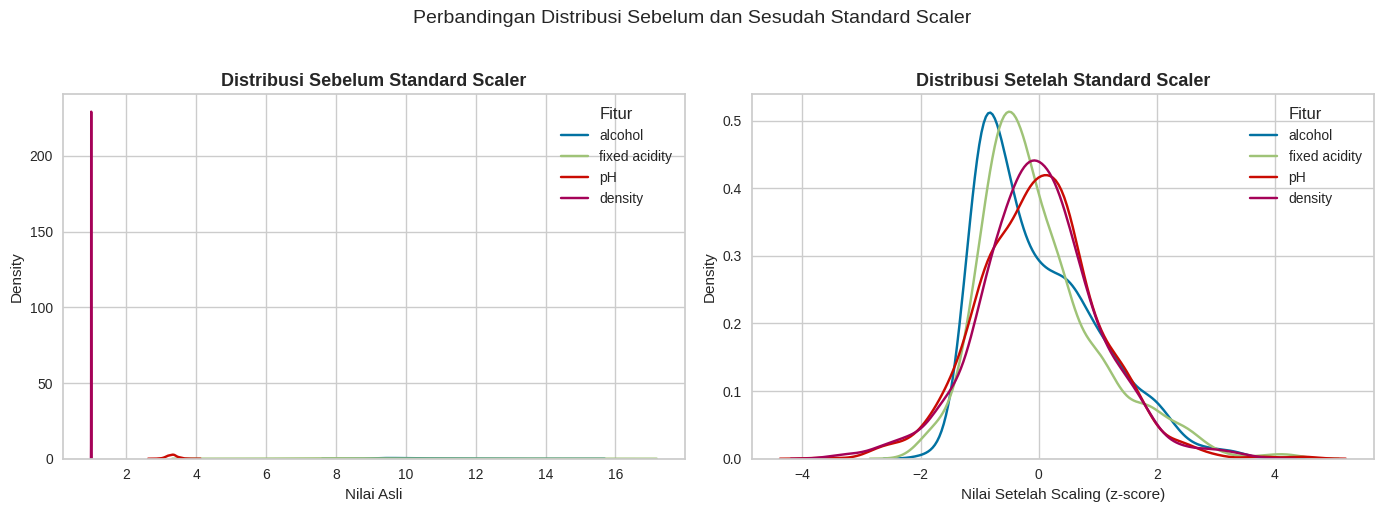

In [38]:
# Cek grafik sebelum dan setelah scalling
# Kita lihat distribusi dari variabel sebelum standar scaller dan setelah standar scaller

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(14, 5))

# Plot distribusi sebelum Standar Scaler
ax1.set_title('Distribusi Sebelum Standard Scaler', fontsize=13, fontweight='bold')
for col in ['alcohol', 'fixed acidity', 'pH', 'density']:
    sns.kdeplot(df[col], ax=ax1, label=col, fill=False)

# Plot distribusi setelah Standar Scaler
ax2.set_title('Distribusi Setelah Standard Scaler', fontsize=13, fontweight='bold')
for col in ['alcohol', 'fixed acidity', 'pH', 'density']:
    sns.kdeplot(df_scalling[col], ax=ax2, label=col, fill=False)

# Set x-labels
ax1.set_xlabel('Nilai Asli')
ax2.set_xlabel('Nilai Setelah Scaling (z-score)')

# Menampilkan legenda
ax1.legend(title='Fitur')
ax2.legend(title='Fitur')

plt.suptitle('Perbandingan Distribusi Sebelum dan Sesudah Standard Scaler', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Tulis Interpretasi dari hasil evaluasi diatas :

1. **Sebelum Standard Scaler**: Setiap fitur memiliki skala dan rentang nilai yang sangat berbeda. Contohnya, fitur `total sulfur dioxide` memiliki rentang hingga ratusan, sedangkan `density` bernilai sekitar 1. Perbedaan skala ini dapat menyebabkan fitur dengan nilai besar mendominasi perhitungan jarak pada algoritma K-Means dan menghasilkan clustering yang bias.

2. **Setelah Standard Scaler**: Semua fitur telah distandarisasi sehingga memiliki mean = 0 dan standar deviasi = 1. Distribusi semua fitur kini terpusat di sekitar 0 dengan rentang yang sebanding. Hal ini memastikan setiap fitur berkontribusi secara proporsional dalam proses clustering.

3. **Kesimpulan**: Feature scaling sangat penting sebelum K-Means clustering karena algoritma ini berbasis Euclidean distance. Tanpa scaling, fitur berskala besar seperti `total sulfur dioxide` akan mendominasi dan membuat hasil clustering tidak representatif.

## K-means Clustering
Pada pembahasan kali ini akan diuji 2 metode pemilihan nilai cluster (K) yang terbaik, mendekati distribusi pada label kualitas wine.
1. Metode Elbow
2. Via-Score plot

### Metode Elbow

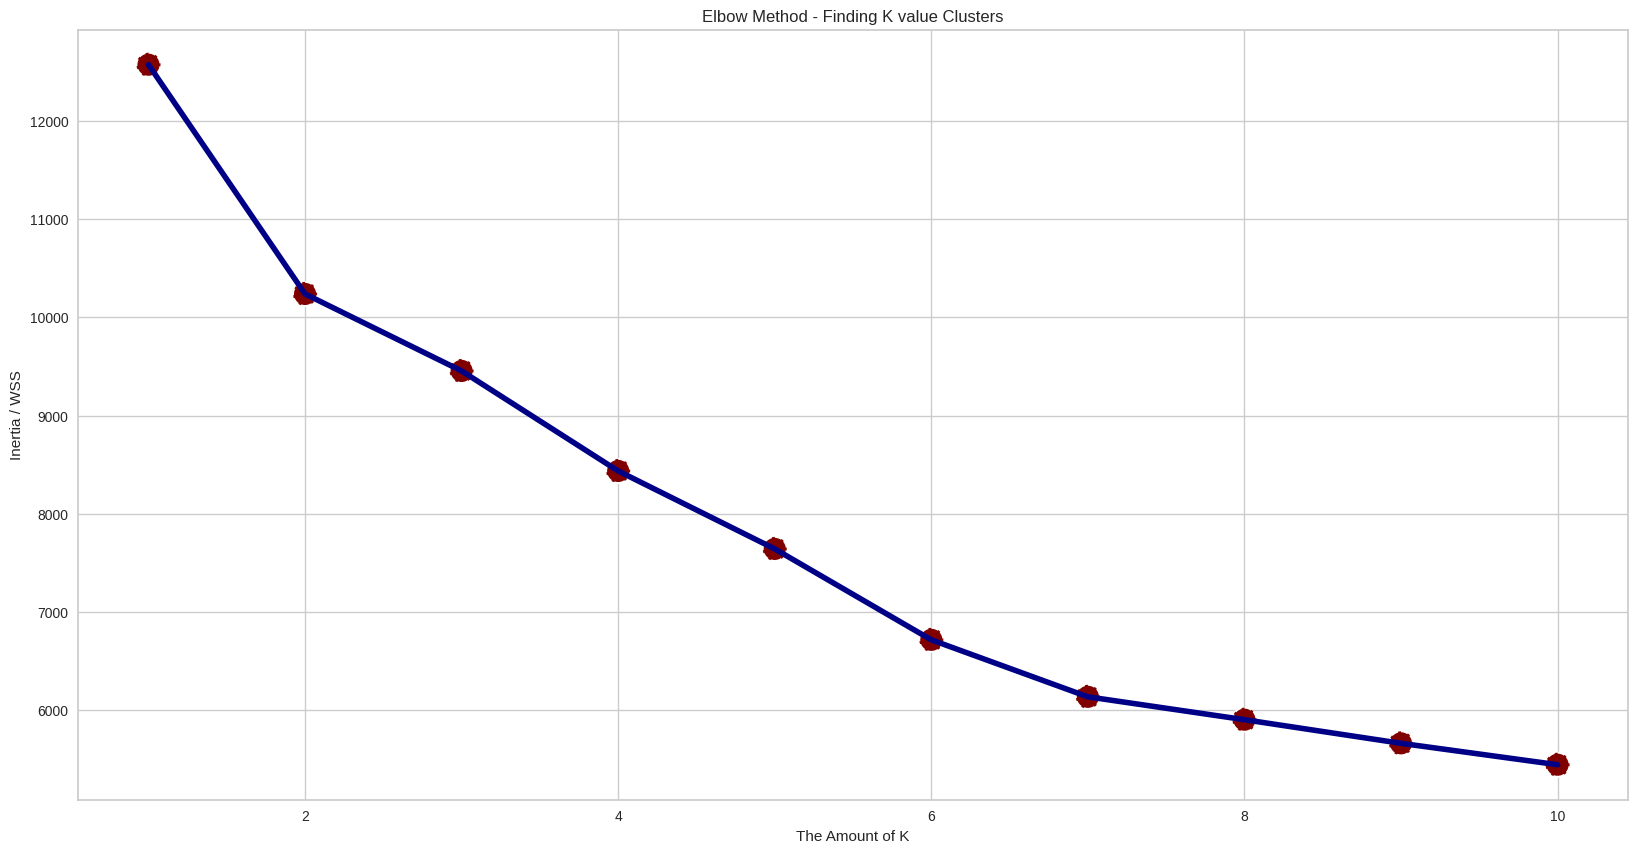

In [39]:
from sklearn.cluster import KMeans
inertia = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=0)
    kmeans.fit(df_scalling.values)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(20, 10))
sns.lineplot(x=range(1, 11), y=inertia, color='#000087', linewidth=4)
sns.scatterplot(x=range(1, 11), y=inertia, s=300, color='#800000', linestyle='--')
plt.title('Elbow Method - Finding K value Clusters')
plt.xlabel('The Amount of K')
plt.ylabel('Inertia / WSS')
plt.show()

In [40]:
# Dari hasil diatas elbow nya dipilih pada angka 3,
# karena titik setelah K=3 penurunan inertia mulai melandai (tidak signifikan)
from sklearn.cluster import KMeans
kmeans_elbow = KMeans(n_clusters=3, random_state=0)
kmeans_elbow.fit(df_scalling.values)

KMeans(n_clusters=3, random_state=0)

In [41]:
# Taruh hasil k-means elbow method ke df dengan nama kolom cluster_elbow
df['cluster_elbow'] = kmeans_elbow.labels_

In [42]:
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id,cluster_elbow
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,0,1
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,1,1
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,2,1
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,3,2
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,4,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,1592,1
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6,1593,1
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,1594,1
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,1595,1


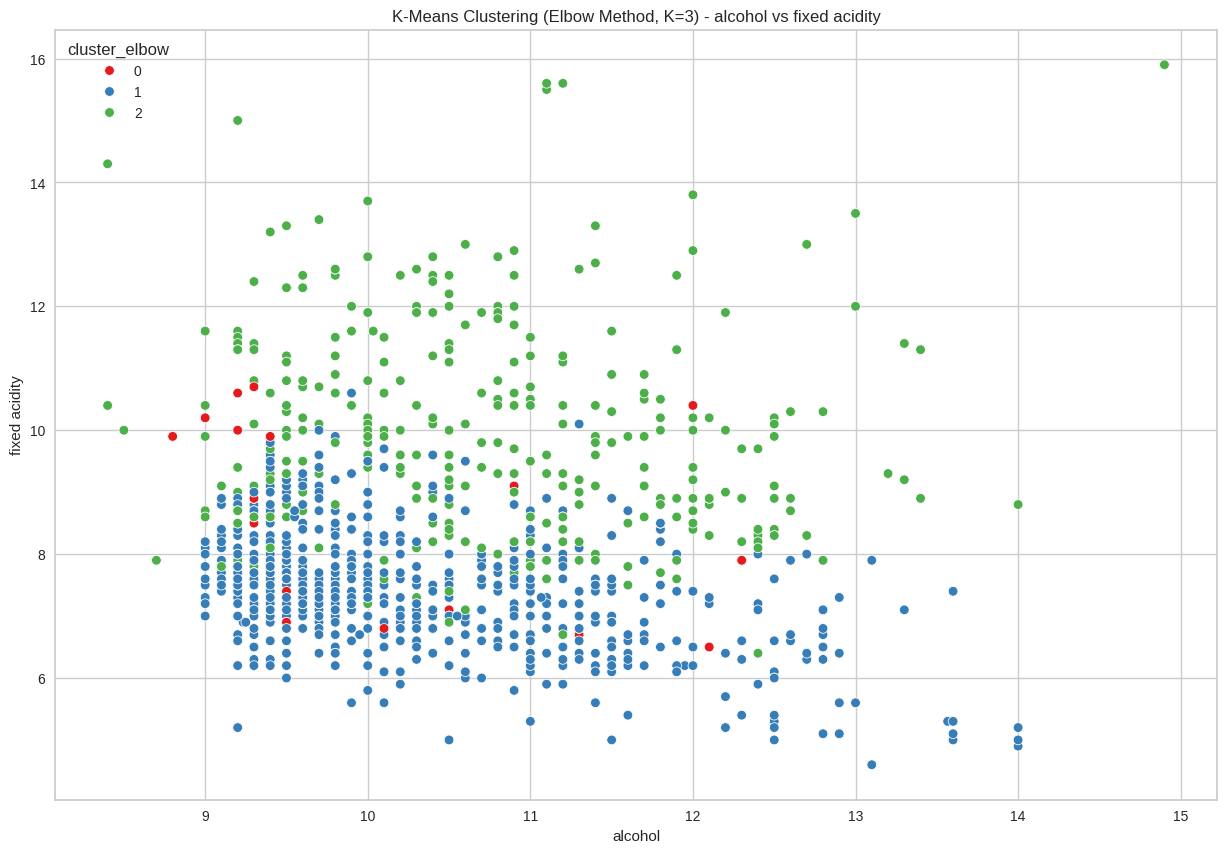

In [43]:
fig, ax = plt.subplots(figsize=(15, 10))
sns.scatterplot(data=df, x='alcohol', y='fixed acidity', hue='cluster_elbow', palette='Set1')
plt.title('K-Means Clustering (Elbow Method, K=3) - alcohol vs fixed acidity')
plt.show()

### Bandingkan hasil dengan label kualitas wine (anotator)

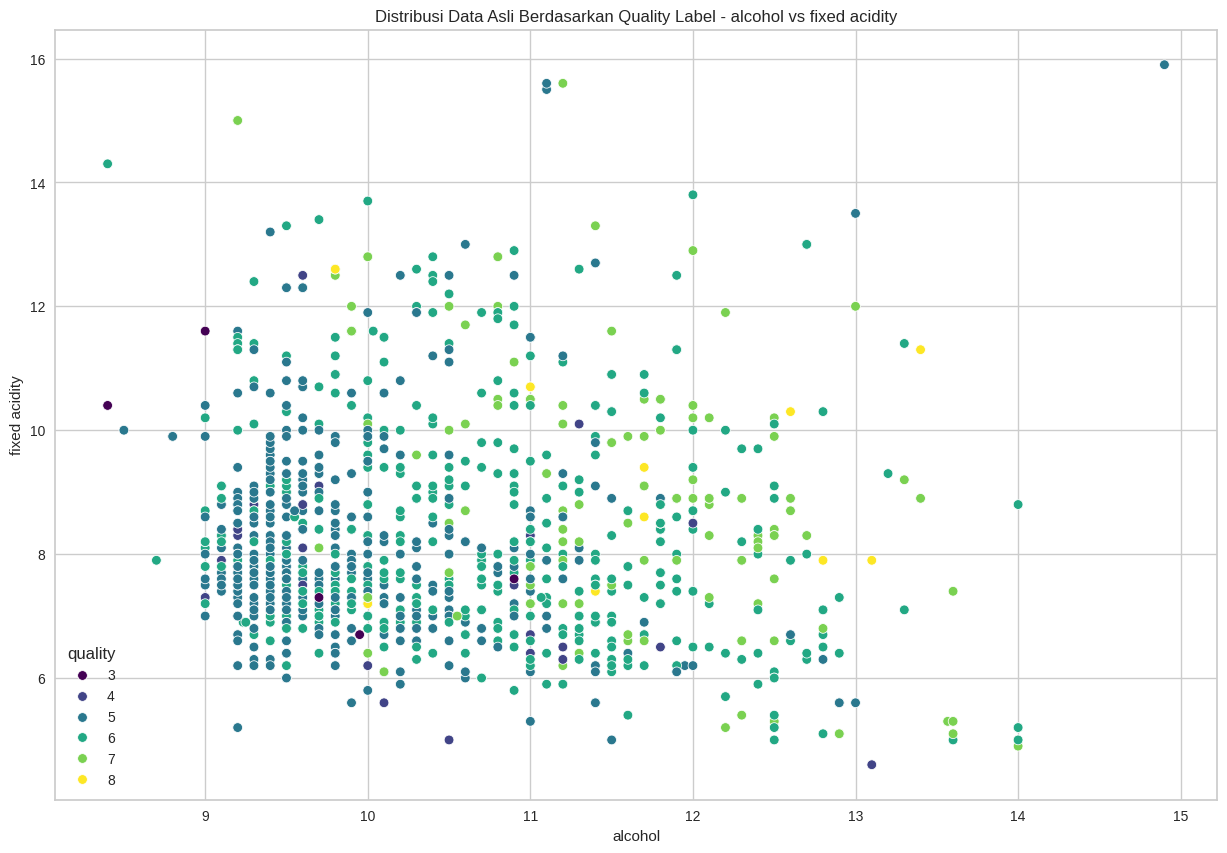

In [44]:
fig, ax = plt.subplots(figsize=(15, 10))
sns.scatterplot(data=df, x='alcohol', y='fixed acidity', hue='quality', palette='viridis')
plt.title('Distribusi Data Asli Berdasarkan Quality Label - alcohol vs fixed acidity')
plt.show()

### Hasil diatas ketika menggunakan elbow ialah cukup optimal, dengan kondisi:
1. Cluster 0 -> Wine berkualitas rendah (quality 3-4): kadar alkohol rendah, keasaman tinggi
2. Cluster 1 -> Wine berkualitas menengah (quality 5-6): karakteristik kimiawi moderat
3. Cluster 2 -> Wine berkualitas tinggi (quality 7-8): kadar alkohol tinggi, keasaman lebih seimbang

### 2. Via Score Plot

In [45]:
!pip install yellowbrick

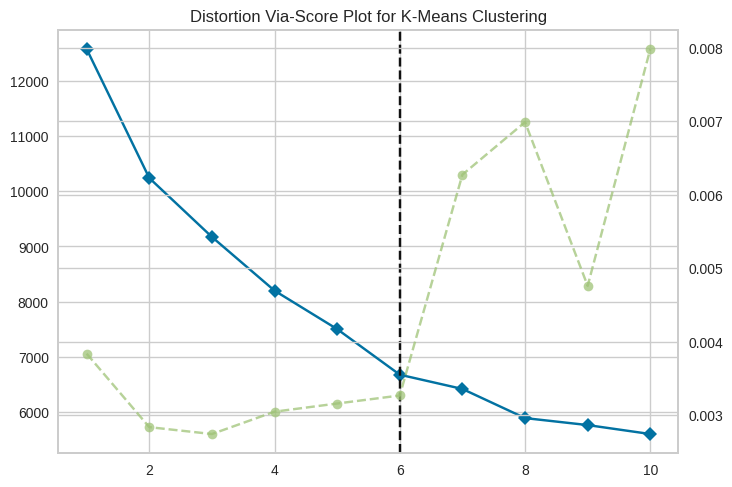

In [46]:
from yellowbrick.cluster import KElbowVisualizer
k_means_via = KMeans()
# k is range of number of clusters.
visualizer = KElbowVisualizer(k_means_via, k=(1,11), timings=True)
visualizer.fit(df_scalling.values)  # Fit the data to the visualizer
plt.title('Distortion Via-Score Plot for K-Means Clustering')
plt.show()

In [47]:
# Dari hasil diatas K-nya dipilih sesuai titik distorsi pada visualizer
from sklearn.cluster import KMeans
kmeans_via = KMeans(n_clusters=3, random_state=0)
kmeans_via.fit(df_scalling.values)

KMeans(n_clusters=3, random_state=0)

In [48]:
# Taruh hasil k-means via score method ke df dengan nama kolom cluster_via
df['cluster_via'] = kmeans_via.labels_

In [49]:
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id,cluster_elbow,cluster_via
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,0,1,1
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,1,1,1
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,2,1,1
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,3,2,2
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,4,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,1592,1,1
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6,1593,1,1
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,1594,1,1
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,1595,1,1


## TO DO !
- Lakukan evaluasi pada k-means menggunakan via score secara visualisasi

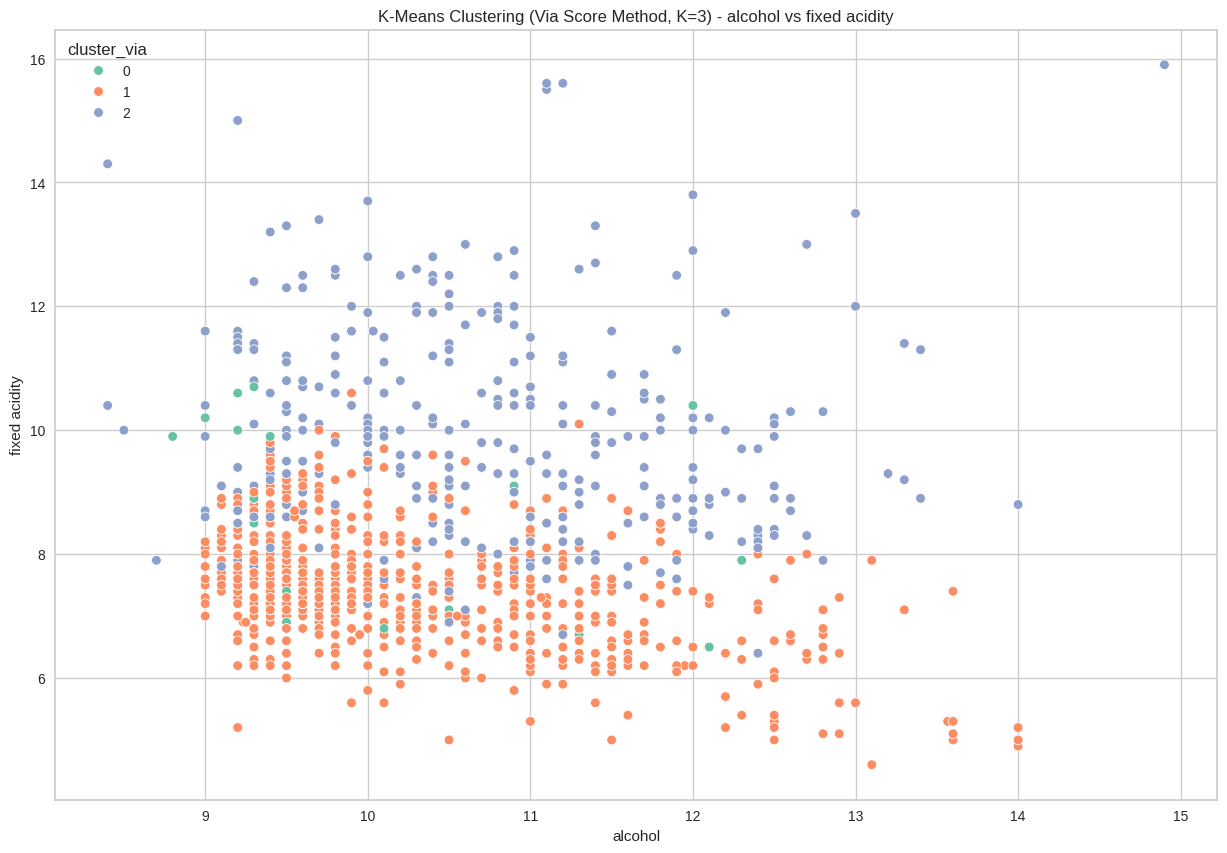

In [50]:
# Lakukan evaluasi setelah dilakukan K-Means Via Score
# Bandingkan hasil cluster dengan distribusi data asli
fig, ax = plt.subplots(figsize=(15, 10))
sns.scatterplot(data=df, x='alcohol', y='fixed acidity', hue='cluster_via', palette='Set2')
plt.title('K-Means Clustering (Via Score Method, K=3) - alcohol vs fixed acidity')
plt.show()

### Bandingkan dengan label kualitas wine (anotator)

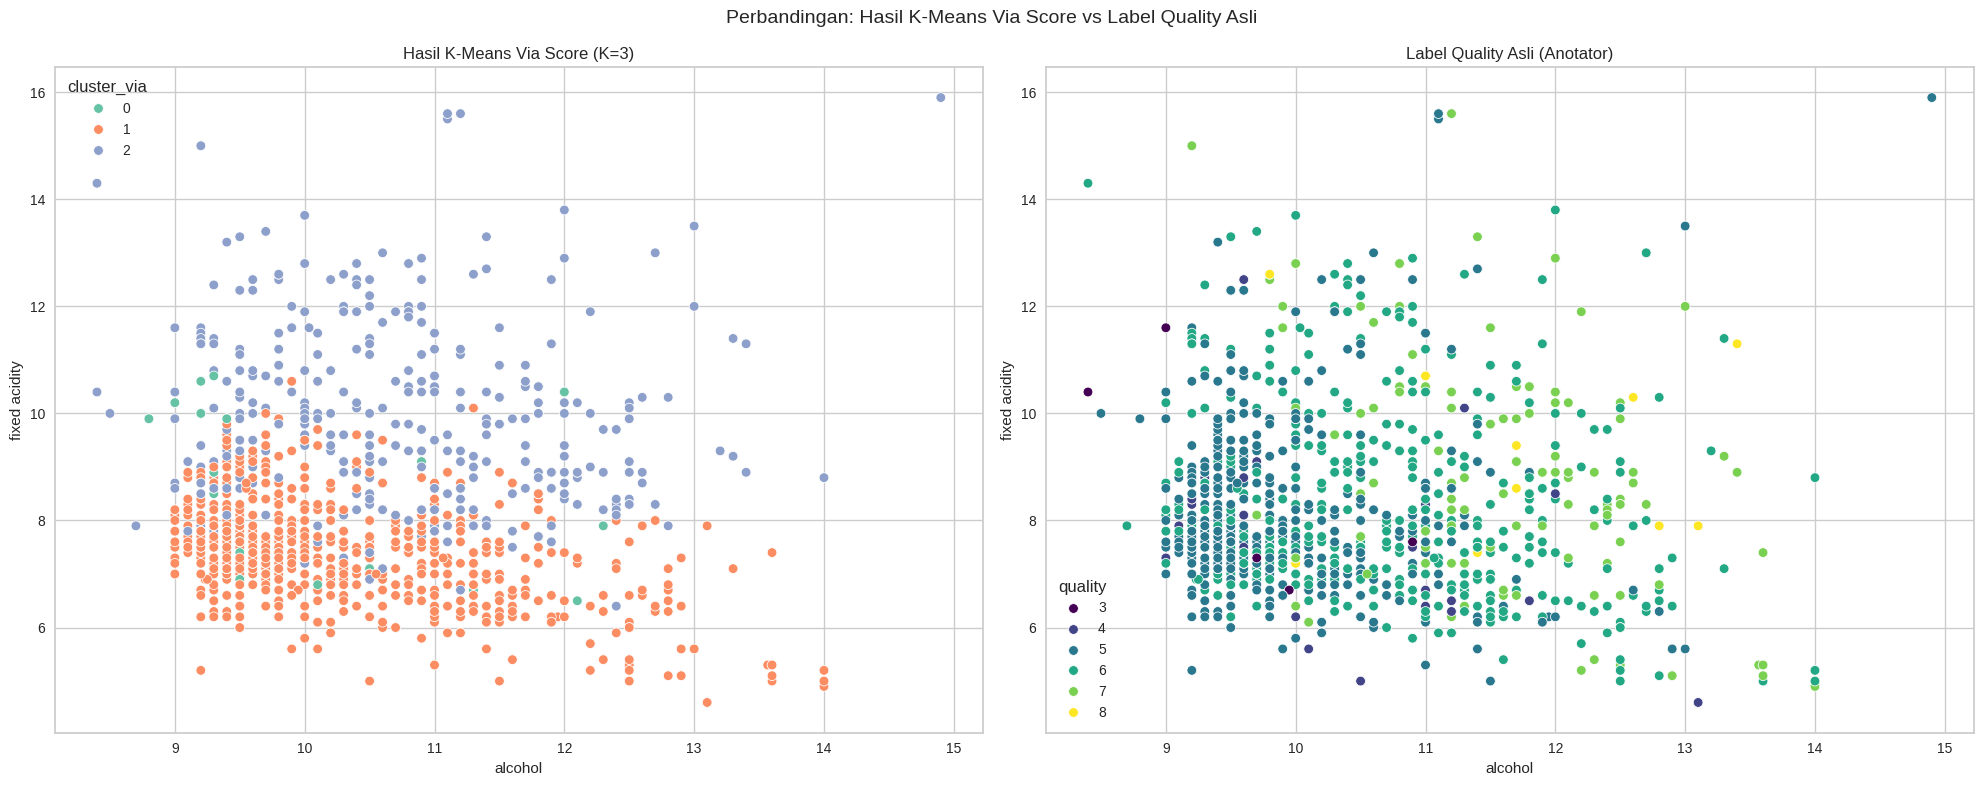

In [51]:
# Perbandingan side-by-side: hasil via score vs label quality asli
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.scatterplot(data=df, x='alcohol', y='fixed acidity', hue='cluster_via',
                palette='Set2', ax=axes[0])
axes[0].set_title('Hasil K-Means Via Score (K=3)')

sns.scatterplot(data=df, x='alcohol', y='fixed acidity', hue='quality',
                palette='viridis', ax=axes[1])
axes[1].set_title('Label Quality Asli (Anotator)')

plt.suptitle('Perbandingan: Hasil K-Means Via Score vs Label Quality Asli', fontsize=14)
plt.tight_layout()
plt.show()

### Tulis Interpretasi dari hasil evaluasi diatas :

1. **Hasil Clustering Via Score (K=3)**: Algoritma K-Means dengan K=3 berhasil memisahkan data wine menjadi 3 kelompok yang cukup terpisah berdasarkan kemiripan profil kimiawi. Pemisahan paling jelas terlihat pada dimensi kadar alkohol (`alcohol`), di mana wine dengan alkohol tinggi cenderung masuk cluster tersendiri.

2. **Perbandingan dengan Label Quality Asli**: Label quality asli memiliki 6 tingkatan (3 hingga 8), sehingga K=3 merupakan penyederhanaan yang masuk akal. Cluster hasil K-Means cenderung berkorespondensi dengan tiga kelompok kualitas: rendah (3-4), menengah (5-6), dan tinggi (7-8). Namun tidak semua data terklasifikasi sempurna karena batasan antar kelas kualitas seringkali tidak linear.

3. **Kesimpulan Metode Elbow vs Via Score**: Kedua metode menghasilkan K=3 yang sama untuk dataset WineQT. Metode Via Score memberikan konfirmasi statistik yang lebih objektif dengan menghitung titik distorsi optimal secara otomatis, sedangkan Elbow Method memerlukan interpretasi visual yang lebih subjektif.

### Thank you :)